In [6]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [7]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/fresno-fog.csv'
if os.path.exists(path):
    Fresno_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/fresno-fog.csv'
    Fresno_rows = pd.read_csv(path, low_memory = False)

print(Fresno_rows)

        Season  Oct.  Nov.  Dec.  Jan.  Feb.  Mar.  Apr.  Total
0    2025-2026     2     5     9   NaN   NaN   NaN   NaN    NaN
1    2024-2025     1     1    17   4.0   3.0   0.0   0.0   26.0
2    2023-2024     0     0     0   7.0   1.0   0.0   1.0    9.0
3    2022-2023     0     1     8   2.0   1.0   0.0   0.0   12.0
4    2021-2022     0    14     9  10.0   0.0   1.0   0.0   34.0
..         ...   ...   ...   ...   ...   ...   ...   ...    ...
111  1914-1915     2     0     9   5.0   3.0   4.0   1.0   24.0
112  1913-1914     0     5    11   7.0  10.0   9.0   2.0   44.0
113  1912-1913     0     2     3   5.0   2.0   0.0   0.0   12.0
114  1911-1912     0     0     6  15.0   7.0   1.0   0.0   29.0
115  1910-1911     0     2    11   4.0   1.0   4.0   1.0   23.0

[116 rows x 9 columns]


In [8]:
Fresno_rows = Fresno_rows.iloc[::-1].reset_index(drop=True)

print(Fresno_rows)

        Season  Oct.  Nov.  Dec.  Jan.  Feb.  Mar.  Apr.  Total
0    1910-1911     0     2    11   4.0   1.0   4.0   1.0   23.0
1    1911-1912     0     0     6  15.0   7.0   1.0   0.0   29.0
2    1912-1913     0     2     3   5.0   2.0   0.0   0.0   12.0
3    1913-1914     0     5    11   7.0  10.0   9.0   2.0   44.0
4    1914-1915     2     0     9   5.0   3.0   4.0   1.0   24.0
..         ...   ...   ...   ...   ...   ...   ...   ...    ...
111  2021-2022     0    14     9  10.0   0.0   1.0   0.0   34.0
112  2022-2023     0     1     8   2.0   1.0   0.0   0.0   12.0
113  2023-2024     0     0     0   7.0   1.0   0.0   1.0    9.0
114  2024-2025     1     1    17   4.0   3.0   0.0   0.0   26.0
115  2025-2026     2     5     9   NaN   NaN   NaN   NaN    NaN

[116 rows x 9 columns]


In [9]:
# Drop the last row 
Fresno_rows = Fresno_rows.iloc[:-1, :]
print(Fresno_rows)

        Season  Oct.  Nov.  Dec.  Jan.  Feb.  Mar.  Apr.  Total
0    1910-1911     0     2    11   4.0   1.0   4.0   1.0   23.0
1    1911-1912     0     0     6  15.0   7.0   1.0   0.0   29.0
2    1912-1913     0     2     3   5.0   2.0   0.0   0.0   12.0
3    1913-1914     0     5    11   7.0  10.0   9.0   2.0   44.0
4    1914-1915     2     0     9   5.0   3.0   4.0   1.0   24.0
..         ...   ...   ...   ...   ...   ...   ...   ...    ...
110  2020-2021     0     0     6   5.0   0.0   0.0   0.0   11.0
111  2021-2022     0    14     9  10.0   0.0   1.0   0.0   34.0
112  2022-2023     0     1     8   2.0   1.0   0.0   0.0   12.0
113  2023-2024     0     0     0   7.0   1.0   0.0   1.0    9.0
114  2024-2025     1     1    17   4.0   3.0   0.0   0.0   26.0

[115 rows x 9 columns]


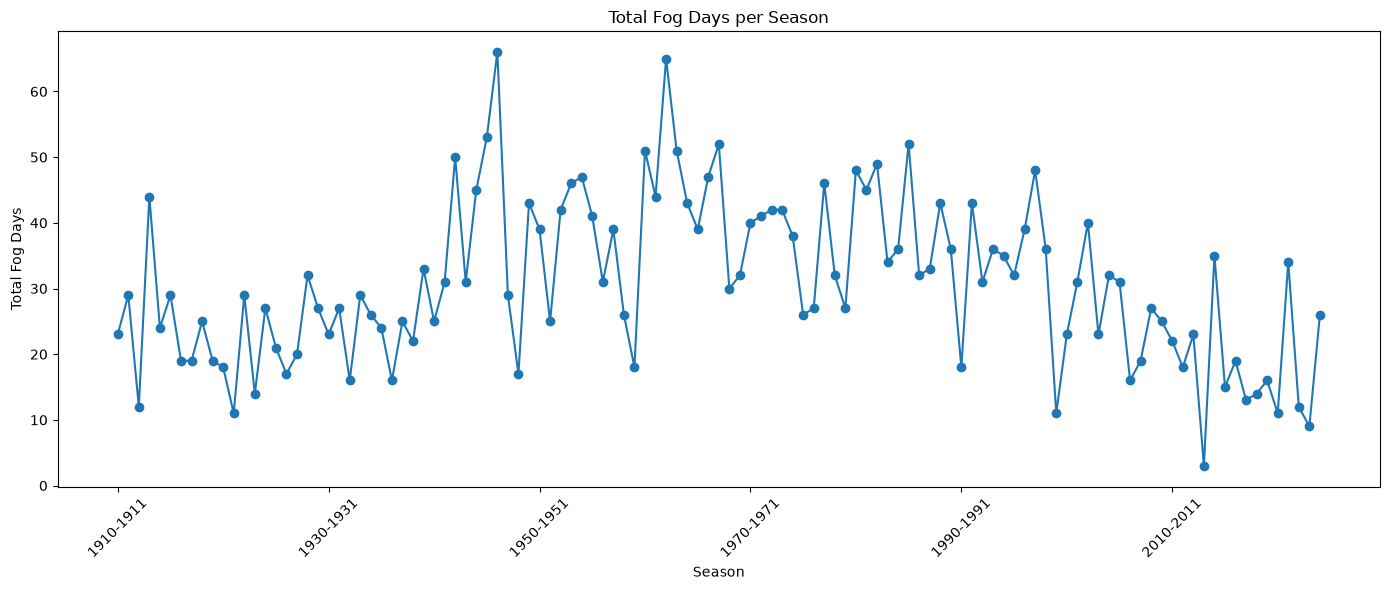

In [12]:
ax = Fresno_rows.plot(
    x='Season',
    y='Total',
    kind='line',
    marker='o',
    figsize=(14, 6),
    legend=False
)

ax.set_title('Total Fog Days per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Total Fog Days')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

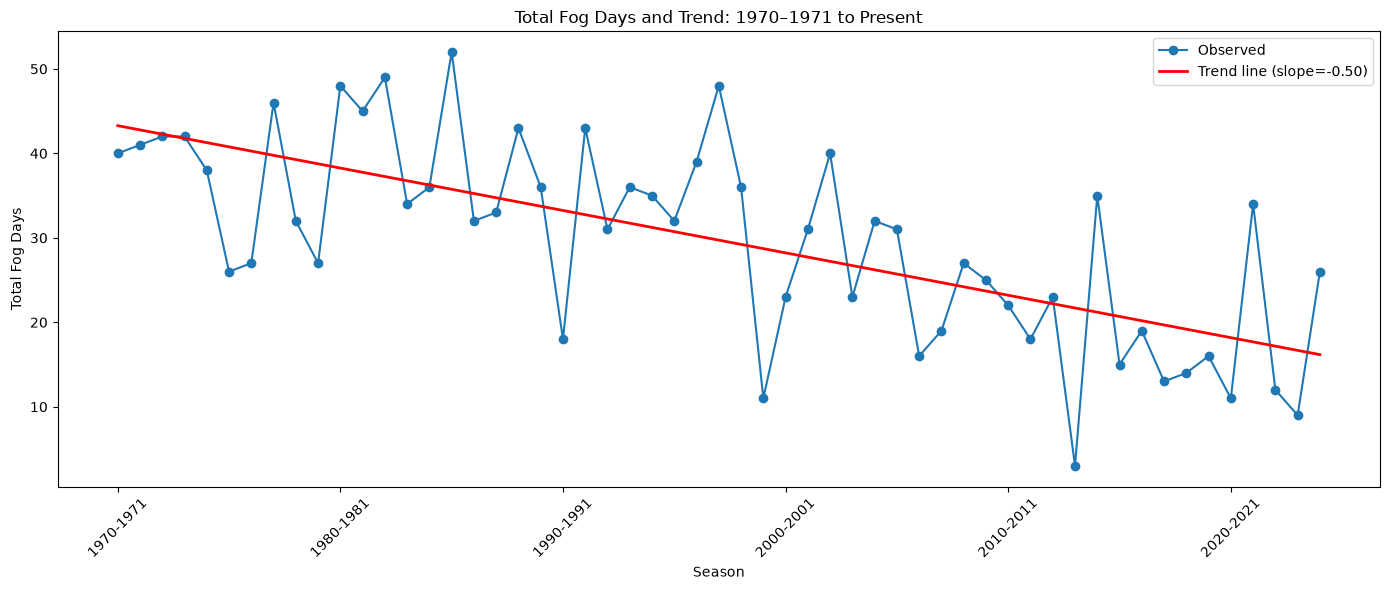

R² = 0.465, p-value = 0.0000000101


In [17]:
trend_data = Fresno_rows.copy()
trend_data["StartYear"] = trend_data["Season"].str[:4].astype(int)
trend_data["Total"] = pd.to_numeric(trend_data["Total"], errors="coerce")

trend_data = trend_data[trend_data["StartYear"] >= 1970].dropna(
    subset=["StartYear", "Total"]
)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    trend_data["StartYear"], trend_data["Total"]
)

trend_data["Trend"] = intercept + slope * trend_data["StartYear"]

trend_ax = trend_data.plot(
    x="Season",
    y="Total",
    kind="line",
    marker="o",
    figsize=(14, 6),
    label="Observed"
)

trend_ax.plot(
    trend_data["Season"],
    trend_data["Trend"],
    color="red",
    linewidth=2,
    label=f"Trend line (slope={slope:.2f})"
)

trend_ax.set_title("Total Fog Days and Trend: 1970–1971 to Present")
trend_ax.set_xlabel("Season")
trend_ax.set_ylabel("Total Fog Days")
trend_ax.tick_params(axis="x", rotation=45)
trend_ax.legend()
plt.tight_layout()
plt.show()

#display the whole p_value instead of it being cut off
print(f"R² = {r_value**2:.3f}, p-value = {p_value:.10f}")

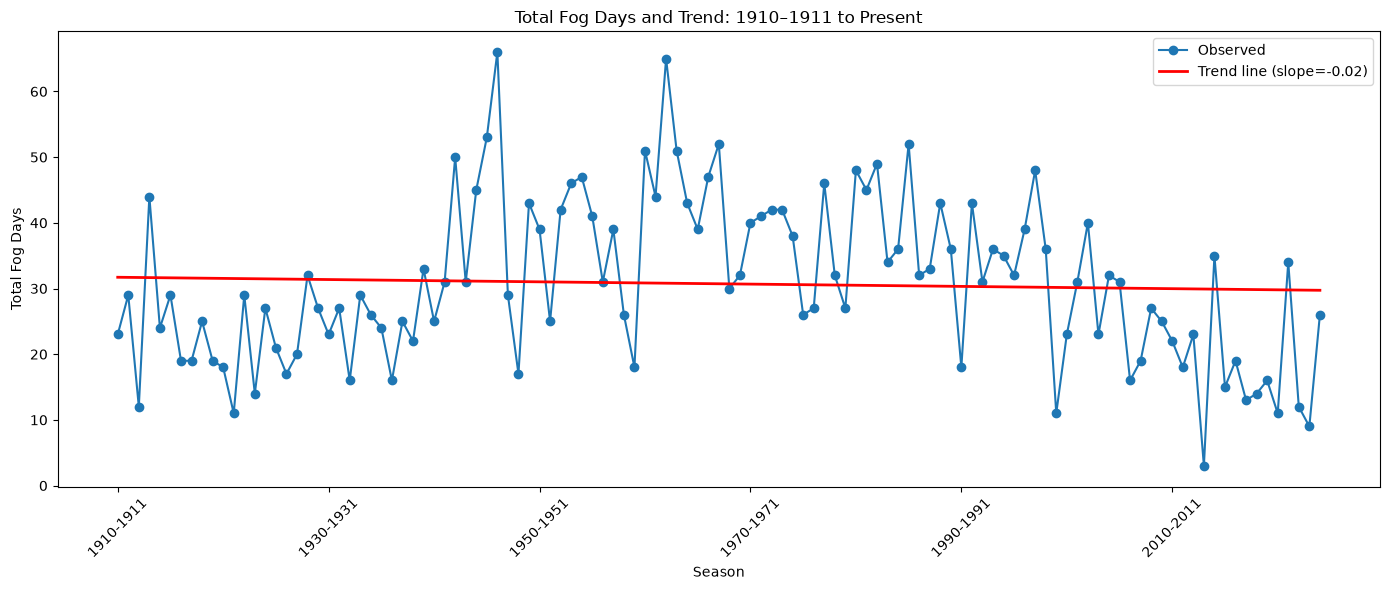

R² = 0.002, p-value = 0.6196


In [19]:
trend_data = Fresno_rows.copy()
trend_data["StartYear"] = trend_data["Season"].str[:4].astype(int)
trend_data["Total"] = pd.to_numeric(trend_data["Total"], errors="coerce")

trend_data = trend_data[trend_data["StartYear"] >= 1910].dropna(
    subset=["StartYear", "Total"]
)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    trend_data["StartYear"], trend_data["Total"]
)

trend_data["Trend"] = intercept + slope * trend_data["StartYear"]

trend_ax = trend_data.plot(
    x="Season",
    y="Total",
    kind="line",
    marker="o",
    figsize=(14, 6),
    label="Observed"
)

trend_ax.plot(
    trend_data["Season"],
    trend_data["Trend"],
    color="red",
    linewidth=2,
    label=f"Trend line (slope={slope:.2f})"
)

trend_ax.set_title("Total Fog Days and Trend: 1910–1911 to Present")
trend_ax.set_xlabel("Season")
trend_ax.set_ylabel("Total Fog Days")
trend_ax.tick_params(axis="x", rotation=45)
trend_ax.legend()
plt.tight_layout()
plt.show()

print(f"R² = {r_value**2:.3f}, p-value = {p_value:.4f}")

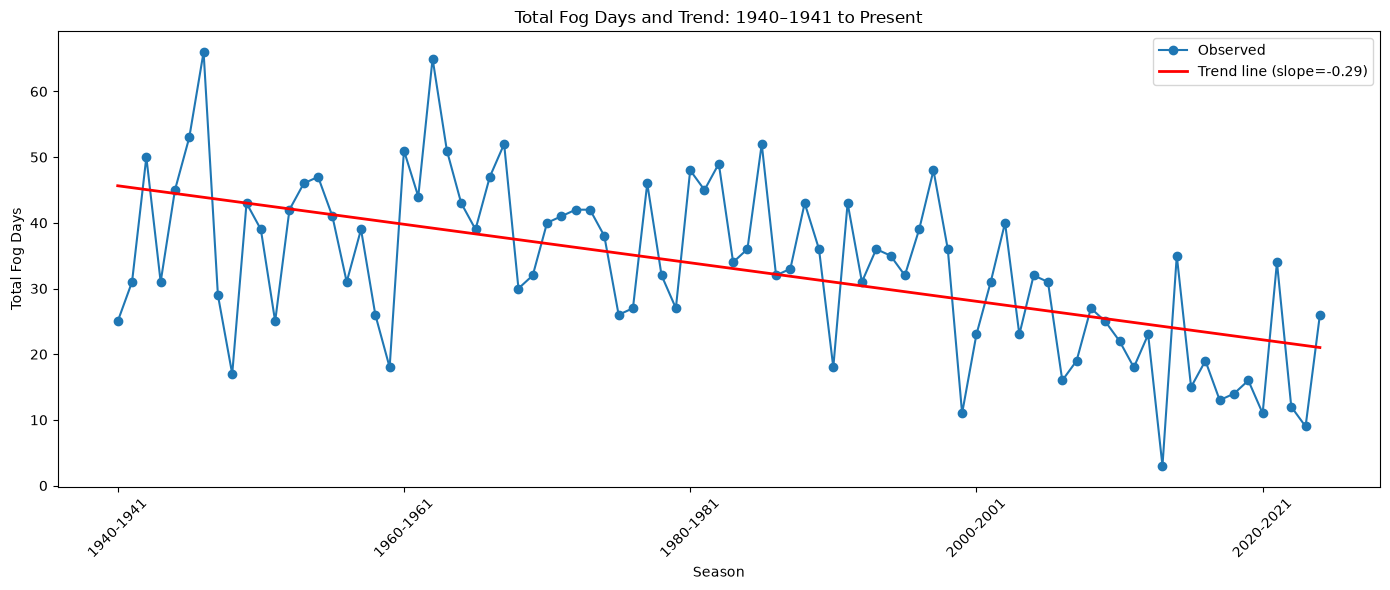

R² = 0.317, p-value = 0.0000000207


In [20]:
trend_data = Fresno_rows.copy()
trend_data["StartYear"] = trend_data["Season"].str[:4].astype(int)
trend_data["Total"] = pd.to_numeric(trend_data["Total"], errors="coerce")

trend_data = trend_data[trend_data["StartYear"] >= 1940].dropna(
    subset=["StartYear", "Total"]
)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    trend_data["StartYear"], trend_data["Total"]
)

trend_data["Trend"] = intercept + slope * trend_data["StartYear"]

trend_ax = trend_data.plot(
    x="Season",
    y="Total",
    kind="line",
    marker="o",
    figsize=(14, 6),
    label="Observed"
)

trend_ax.plot(
    trend_data["Season"],
    trend_data["Trend"],
    color="red",
    linewidth=2,
    label=f"Trend line (slope={slope:.2f})"
)

trend_ax.set_title("Total Fog Days and Trend: 1940–1941 to Present")
trend_ax.set_xlabel("Season")
trend_ax.set_ylabel("Total Fog Days")
trend_ax.tick_params(axis="x", rotation=45)
trend_ax.legend()
plt.tight_layout()
plt.show()

print(f"R² = {r_value**2:.3f}, p-value = {p_value:.10f}")

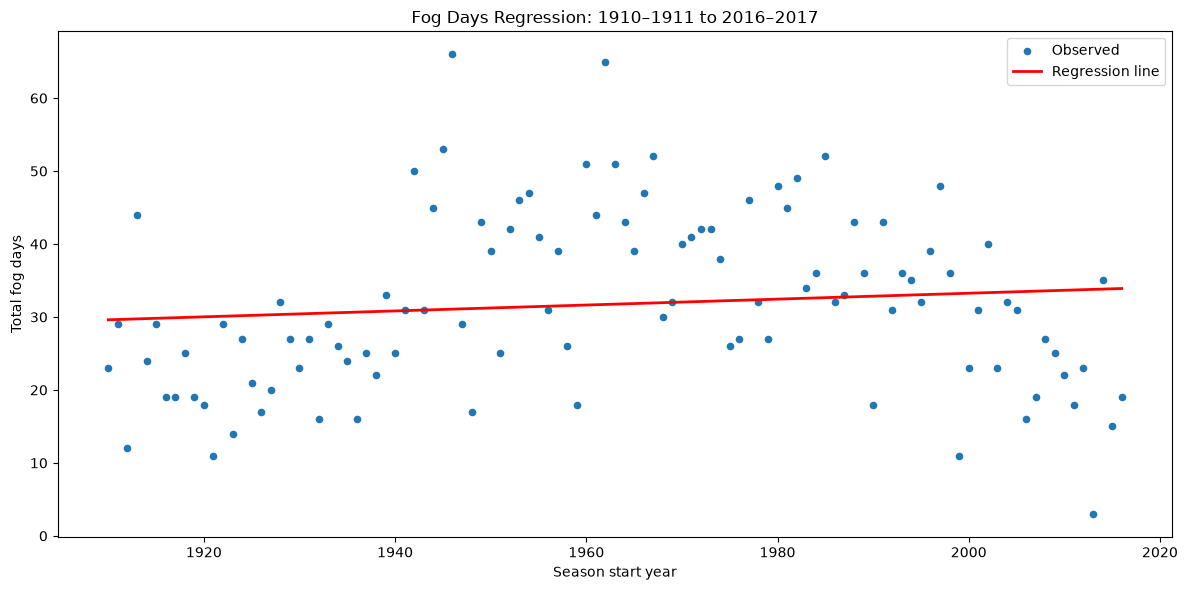

Slope: 0.0404 fog days/year
Intercept: -47.6261
R²: 0.0109
p-value: 0.2847290406
Standard error: 0.0376


In [21]:
regression_data = Fresno_rows.copy()
regression_data["StartYear"] = regression_data["Season"].str[:4].astype(int)
regression_data["Total"] = pd.to_numeric(
    regression_data["Total"], errors="coerce"
)

regression_data = regression_data[
    (regression_data["StartYear"] >= 1910) &
    (regression_data["StartYear"] <= 2016)
].dropna(subset=["StartYear", "Total"])

slope_1910_2016, intercept_1910_2016, r_value_1910_2016, p_value_1910_2016, std_err_1910_2016 = (
    stats.linregress(
        regression_data["StartYear"],
        regression_data["Total"]
    )
)

regression_data["Predicted"] = (
    intercept_1910_2016
    + slope_1910_2016 * regression_data["StartYear"]
)

regression_ax = regression_data.plot(
    x="StartYear",
    y="Total",
    kind="scatter",
    figsize=(12, 6),
    label="Observed"
)

regression_ax.plot(
    regression_data["StartYear"],
    regression_data["Predicted"],
    color="red",
    linewidth=2,
    label="Regression line"
)

regression_ax.set_title("Fog Days Regression: 1910–1911 to 2016–2017")
regression_ax.set_xlabel("Season start year")
regression_ax.set_ylabel("Total fog days")
regression_ax.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {slope_1910_2016:.4f} fog days/year")
print(f"Intercept: {intercept_1910_2016:.4f}")
print(f"R²: {r_value_1910_2016**2:.4f}")
print(f"p-value: {p_value_1910_2016:.10f}")
print(f"Standard error: {std_err_1910_2016:.4f}")

In [33]:
# read in a cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/HeavyFog_data.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/HeavyFog_data.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

       STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0     USW00053119  36.31889 -119.62889  2006-01-31 23:59:00   
1     USW00053119  36.31889 -119.62889  2006-02-28 23:59:00   
2     USW00053119  36.31889 -119.62889  2006-03-31 23:59:00   
3     USW00053119  36.31889 -119.62889  2006-04-30 23:59:00   
4     USW00053119  36.31889 -119.62889  2006-10-31 23:59:00   
...           ...       ...        ...                  ...   
2480  USW00024257  40.51750 -122.29860  2024-11-30 23:59:00   
2481  USW00024257  40.51750 -122.29860  2025-02-28 23:59:00   
2482  USW00024257  40.51750 -122.29860  2025-03-31 23:59:00   
2483  USW00024257  40.51750 -122.29860  2026-01-31 23:59:00   
2484  USW00024257  40.51750 -122.29860  2026-02-28 23:59:00   

      HourlyPrecipitation  HourlyVisibility  MonthlyNumberDaysWithHeavyFog  \
0                     NaN               NaN                           19.0   
1                     NaN               NaN                           16.0   
2        

In [36]:
heavy_fog_data = CV_rows.copy()
heavy_fog_data["DATE"] = pd.to_datetime(heavy_fog_data["DATE"], errors="coerce")
heavy_fog_data["MonthlyNumberDaysWithHeavyFog"] = pd.to_numeric(
    heavy_fog_data["MonthlyNumberDaysWithHeavyFog"], errors="coerce"
)

heavy_fog_data = heavy_fog_data[
    heavy_fog_data["DATE"].dt.month.isin([11, 12, 1, 2, 3])
].dropna(subset=["STATION", "DATE", "MonthlyNumberDaysWithHeavyFog"])

heavy_fog_data["SeasonStart"] = heavy_fog_data["DATE"].dt.year.where(
    heavy_fog_data["DATE"].dt.month.isin([11, 12]),
    heavy_fog_data["DATE"].dt.year - 1
)
heavy_fog_data["season"] = (
    heavy_fog_data["SeasonStart"].astype(str)
    + "-"
    + (heavy_fog_data["SeasonStart"] + 1).astype(str)
)

month_columns = {
    11: "november",
    12: "december",
    1: "january",
    2: "february",
    3: "march",
}
heavy_fog_data["month"] = heavy_fog_data["DATE"].dt.month.map(month_columns)

heavy_fog_seasons = (
    heavy_fog_data.pivot_table(
        index=["STATION", "season"],
        columns="month",
        values="MonthlyNumberDaysWithHeavyFog",
        aggfunc="sum"
    )
    .reindex(columns=["november", "december", "january", "february", "march"])
    .reset_index()
    .rename(columns={"STATION": "station"})
)

heavy_fog_seasons["total"] = heavy_fog_seasons[
    ["november", "december", "january", "february", "march"]
].sum(axis=1, min_count=1)

heavy_fog_seasons = heavy_fog_seasons[
    ["station", "season", "november", "december", "january", "february", "march", "total"]
]

display(heavy_fog_seasons)

month,station,season,november,december,january,february,march,total
0,BAKERSFIELD AP,1964-1965,NaN,NaN,13.0,1.0,NaN,14.0
1,BAKERSFIELD AP,1965-1966,5.0,17.0,7.0,3.0,NaN,32.0
2,BAKERSFIELD AP,1966-1967,4.0,12.0,9.0,6.0,1.0,32.0
3,BAKERSFIELD AP,1967-1968,4.0,7.0,8.0,9.0,NaN,28.0
4,BAKERSFIELD AP,1968-1969,4.0,6.0,8.0,3.0,NaN,21.0
...,...,...,...,...,...,...,...,...
549,VACAVILLE/NUT TREE AP ASOS,2021-2022,10.0,9.0,4.0,NaN,NaN,23.0
550,VACAVILLE/NUT TREE AP ASOS,2022-2023,NaN,9.0,1.0,NaN,NaN,10.0
551,VACAVILLE/NUT TREE AP ASOS,2023-2024,NaN,3.0,4.0,NaN,NaN,7.0
552,VACAVILLE/NUT TREE AP ASOS,2024-2025,5.0,5.0,1.0,NaN,NaN,11.0


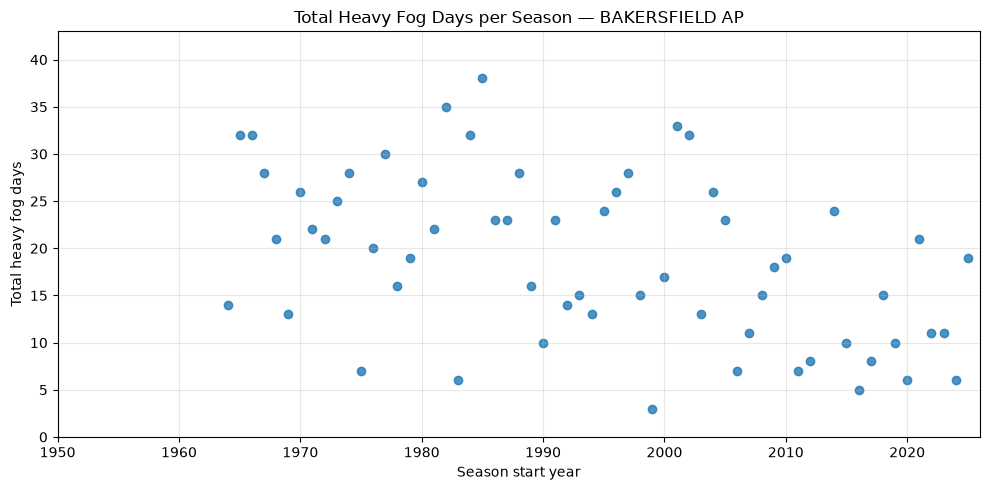

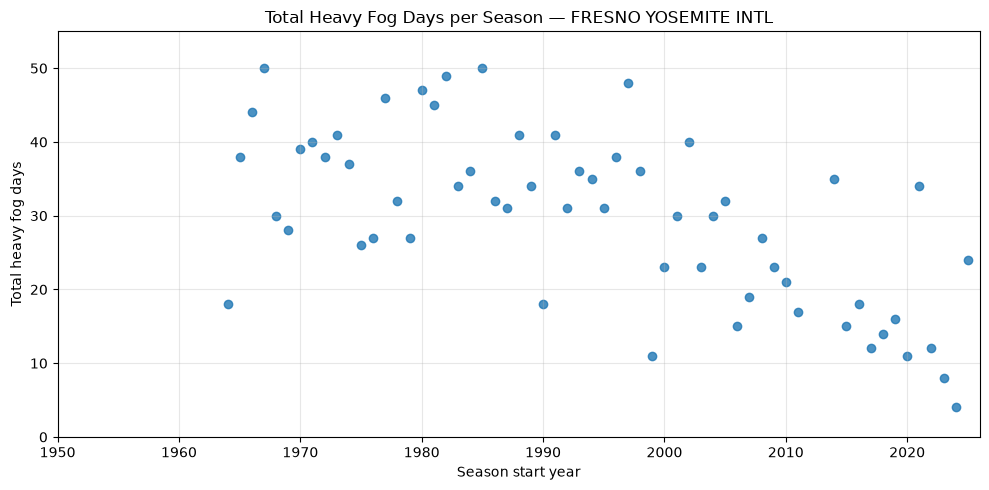

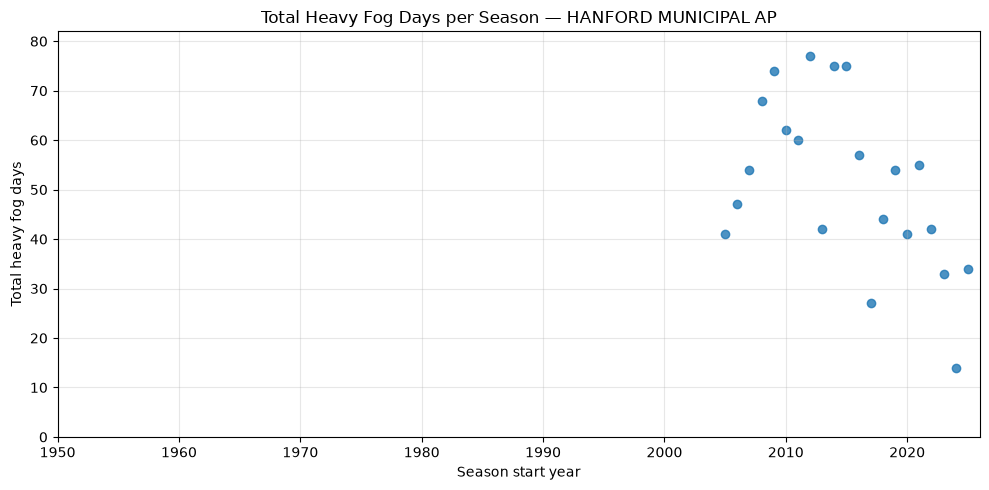

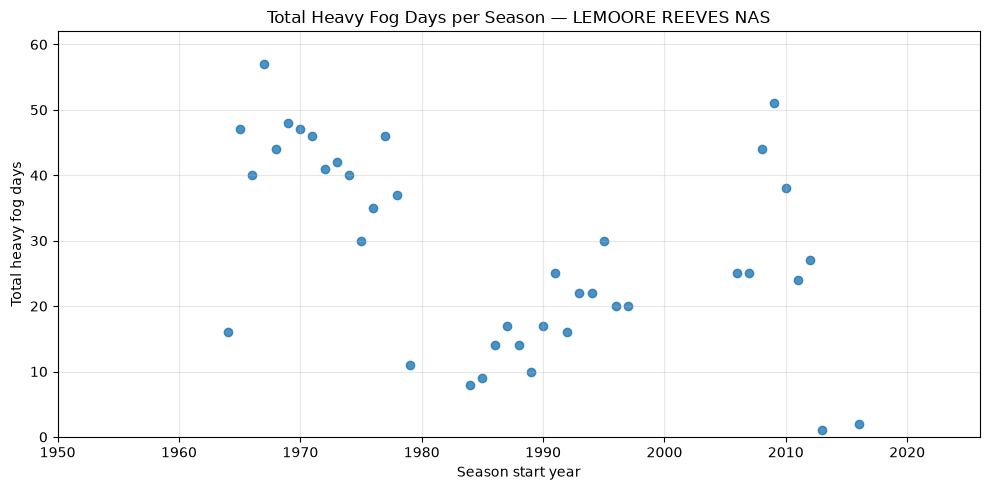

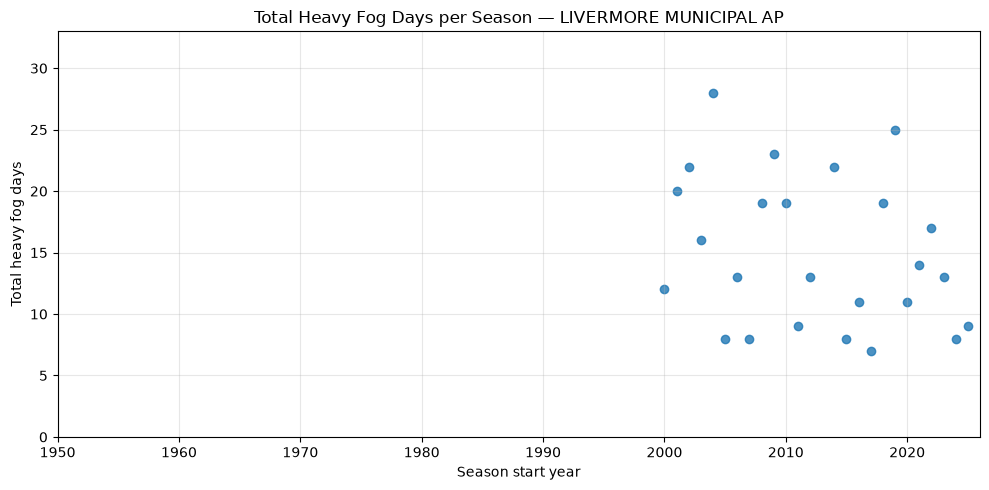

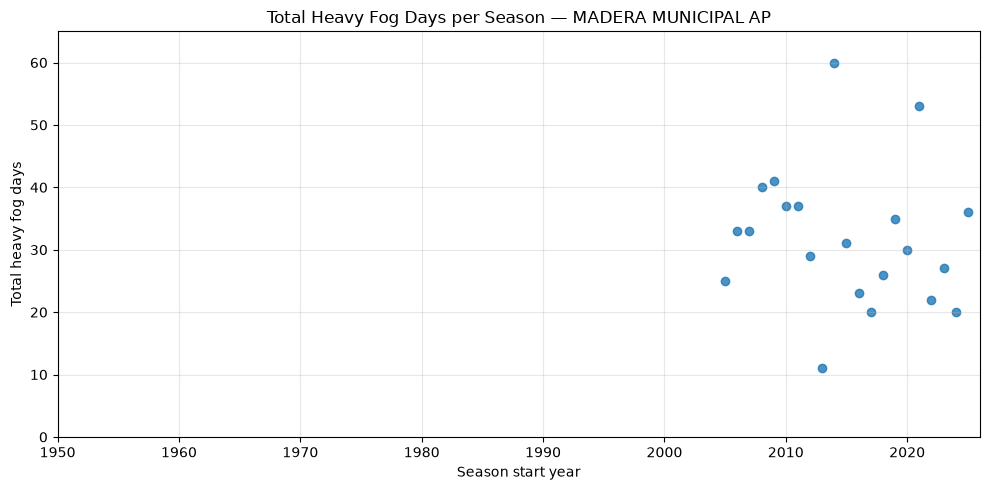

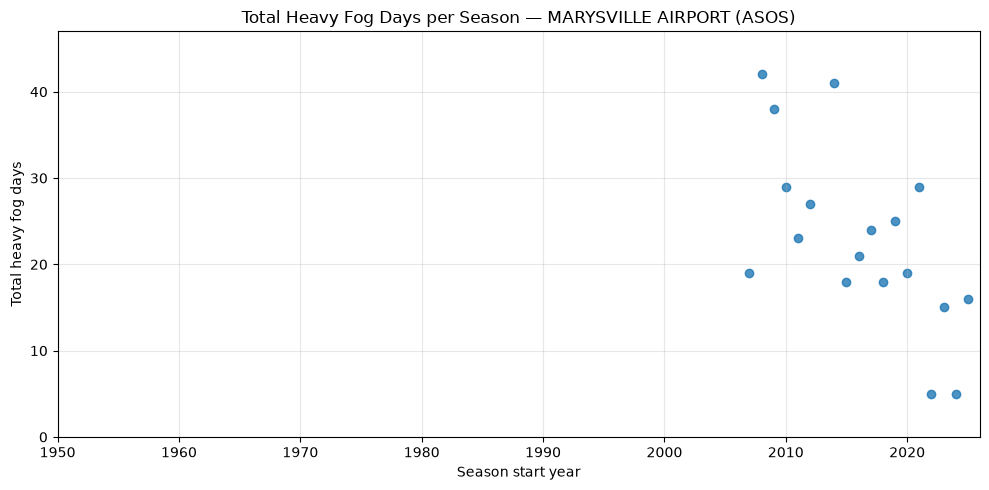

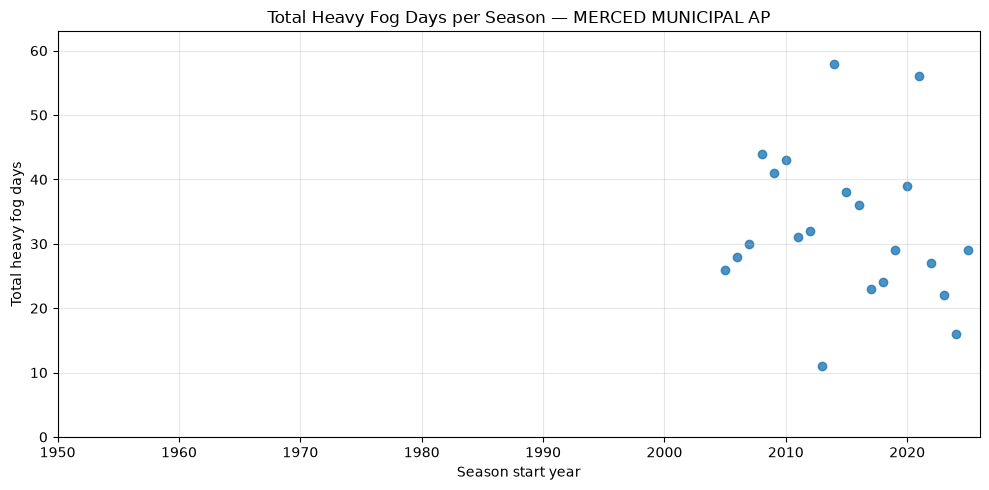

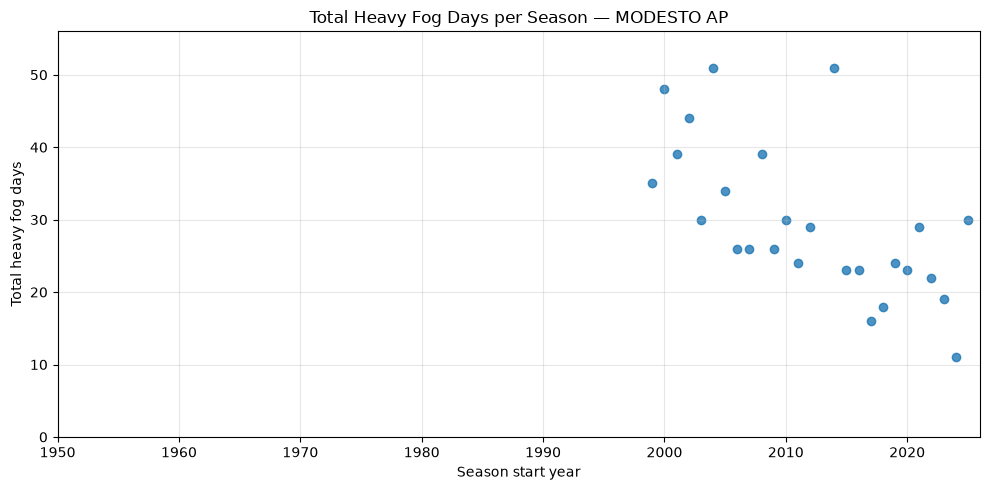

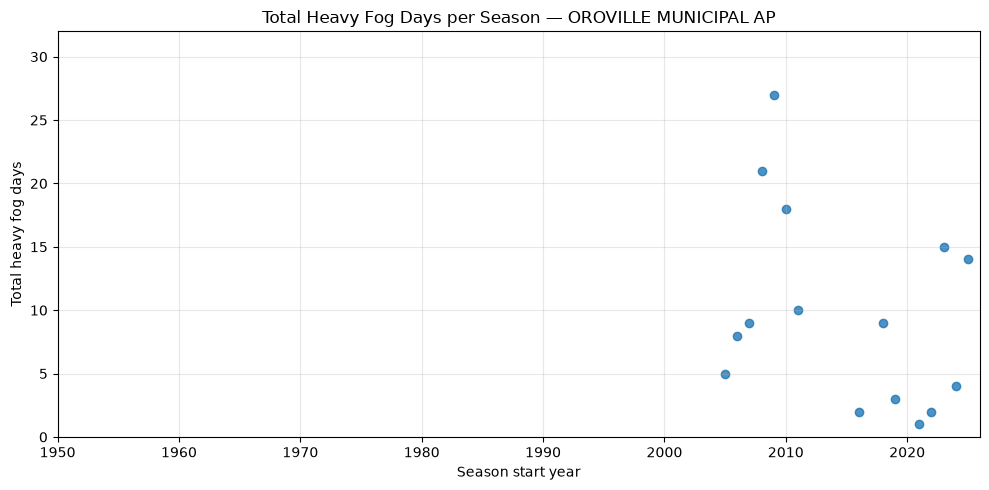

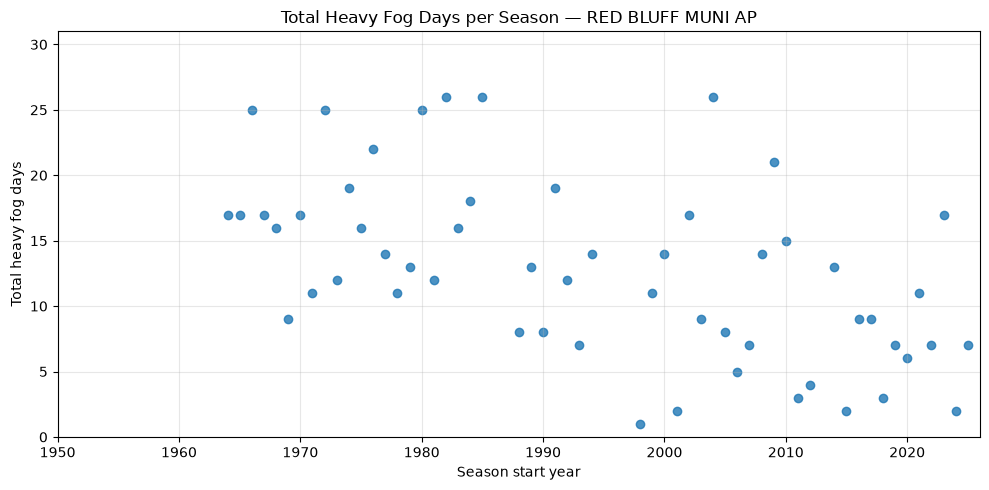

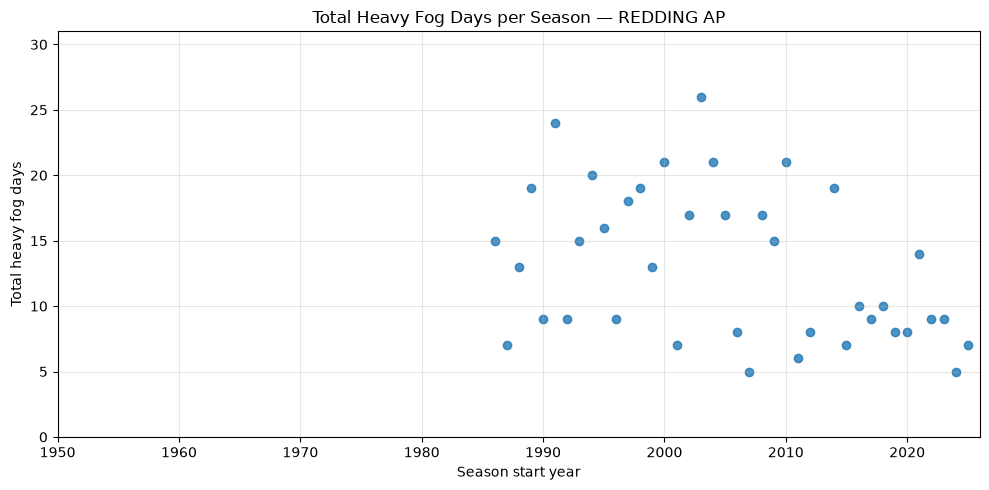

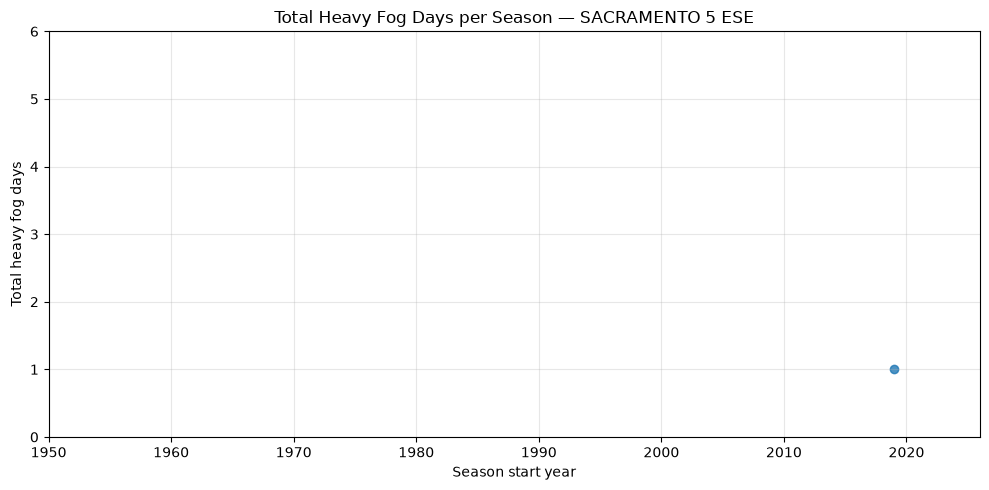

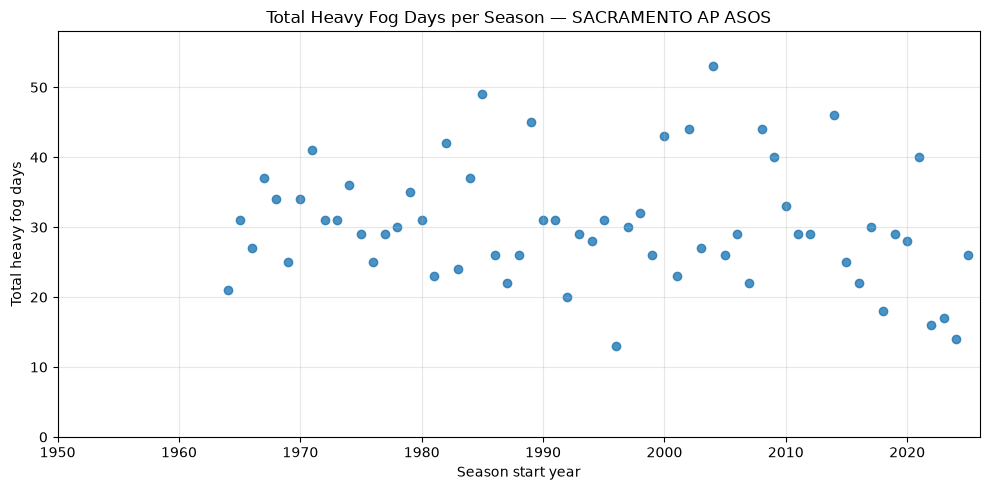

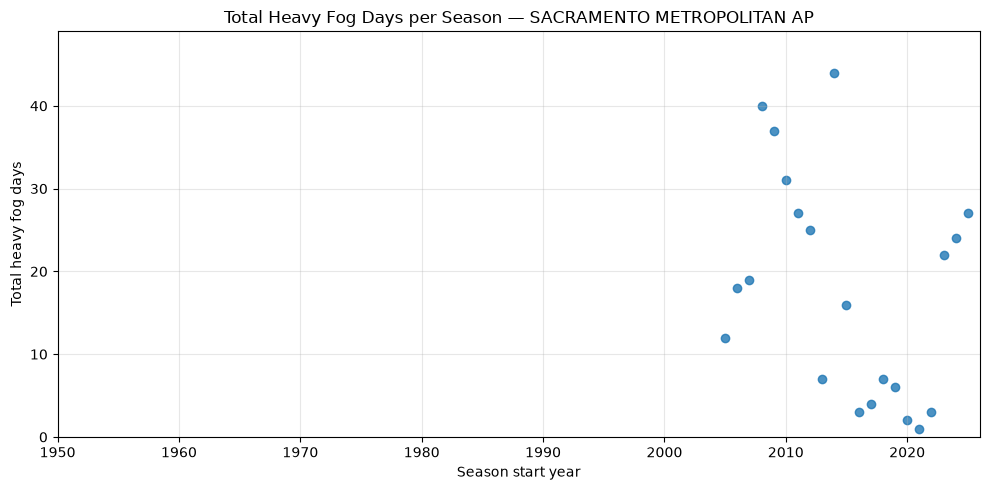

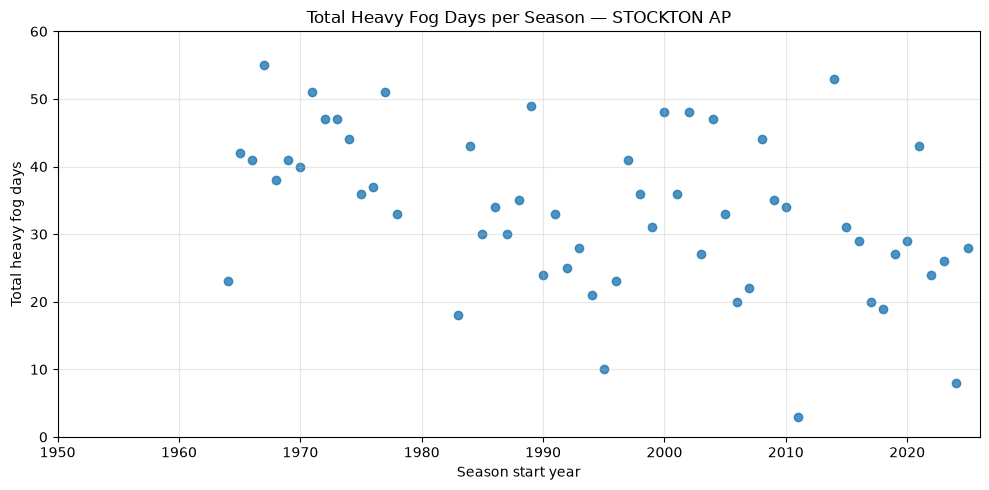

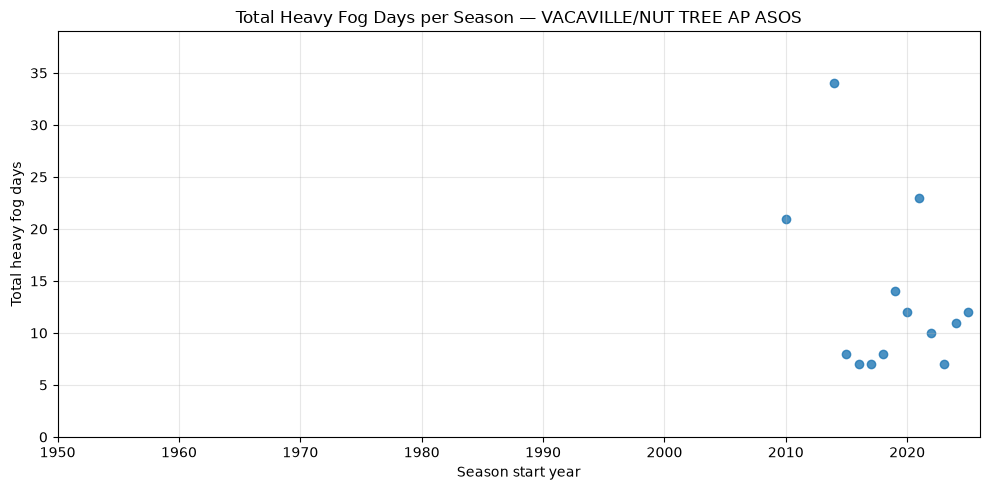

In [39]:
# Create one scatter plot per station, with season start year on the x-axis.
# Make all plots have axes from 1950 to 2026
plot_data = heavy_fog_seasons.copy()
plot_data["Year"] = plot_data["season"].str[:4].astype(int)
plot_data["total"] = pd.to_numeric(plot_data["total"], errors="coerce")

for station, station_data in plot_data.groupby("station"):
    station_data = station_data.dropna(subset=["Year", "total"]).sort_values("Year")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(station_data["Year"], station_data["total"], alpha=0.8)
    ax.set_title(f"Total Heavy Fog Days per Season — {station}")
    ax.set_xlabel("Season start year")
    ax.set_ylabel("Total heavy fog days")
    ax.set_xlim(1950, 2026)
    ax.set_ylim(0, station_data["total"].max() + 5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()